In [1]:
import pandas as pd

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
print("shape:", df.shape)


First 5 Rows
shape: (1470, 35)


In [5]:
print("\nFirst 5 Rows")
df.head()


First 5 Rows


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [8]:
print("\nMissing values:", df.isnull().sum().sum())


Missing values: 0


In [12]:
print(df['Attrition'].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [13]:
print(df.select_dtypes(include='number').shape[1])
print(df.select_dtypes(include='object').shape[1])

28
8


In [14]:
print(df['Age'].mean().round(1))
print("Avg Monthly Income: $", df['MonthlyIncome'].mean().round(0))
print("Avg Years at Company:", df['YearsAtCompany'].mean().round(1))

36.9
Avg Monthly Income: $ 6503.0
Avg Years at Company: 7.0


# Data Cleaning 

In [9]:
print(df.duplicated().sum())

0


In [10]:
print(df.dtypes)

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [11]:
# Convert Attrition to numbers
df['Attrition_Num'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Convert OverTime to numbers
df['OverTime_Num'] = df['OverTime'].map({'Yes': 1, 'No': 0})

# Drop Over18 — every single employee is Y, it tells us nothing
df = df.drop(columns=['Over18'])

# Confirm
print("Attrition_Num:", df['Attrition_Num'].value_counts().to_dict())
print("OverTime_Num:", df['OverTime_Num'].value_counts().to_dict())
print("Columns remaining:", df.shape[1])


Attrition_Num: {0: 1233, 1: 237}
OverTime_Num: {0: 1054, 1: 416}
Columns remaining: 36


# Outlier Check

In [16]:
cols_to_check = ['MonthlyIncome', 'Age', 'YearsAtCompany', 'DistanceFromHome']

for col in cols_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"{col}: {outliers} outliers (range: {lower:.0f} to {upper:.0f})")

MonthlyIncome: 114 outliers (range: -5291 to 16581)
Age: 0 outliers (range: 10 to 62)
YearsAtCompany: 104 outliers (range: -6 to 18)
DistanceFromHome: 0 outliers (range: -16 to 32)


Kept all the outliers, as this is the real employees data 

#  EDA

C:\Users\anith\AppData\Local\Temp\ipykernel_20608\937520497.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_attrition.index, y=dept_attrition.values, palette='Blues_d')


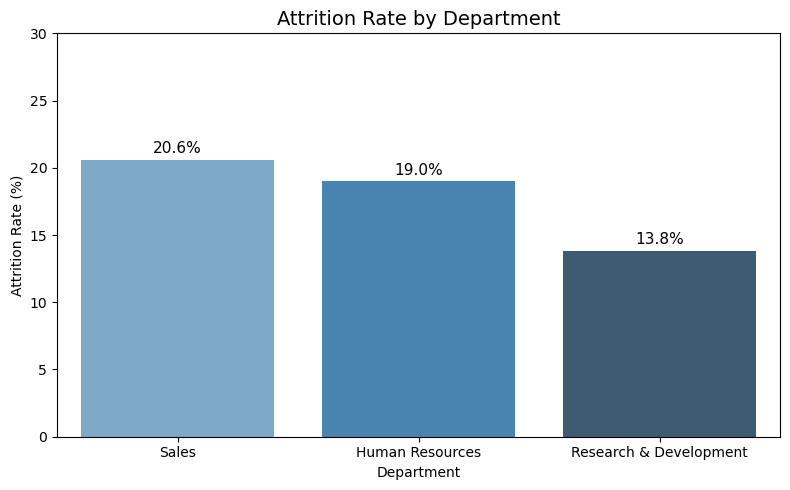

Department
Sales                     20.6
Human Resources           19.0
Research & Development    13.8
Name: Attrition_Num, dtype: float64


In [18]:
# Attrition rate by department
dept_attrition = df.groupby('Department')['Attrition_Num'].mean().mul(100).round(1)
dept_attrition = dept_attrition.sort_values(ascending=False)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=dept_attrition.index, y=dept_attrition.values, palette='Blues_d')
plt.title('Attrition Rate by Department', fontsize=14)
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.ylim(0, 30)

# Add % labels on bars
for i, val in enumerate(dept_attrition.values):
    plt.text(i, val + 0.5, f'{val}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

# Print the numbers too
print(dept_attrition)

# Does overtime cause attrition?

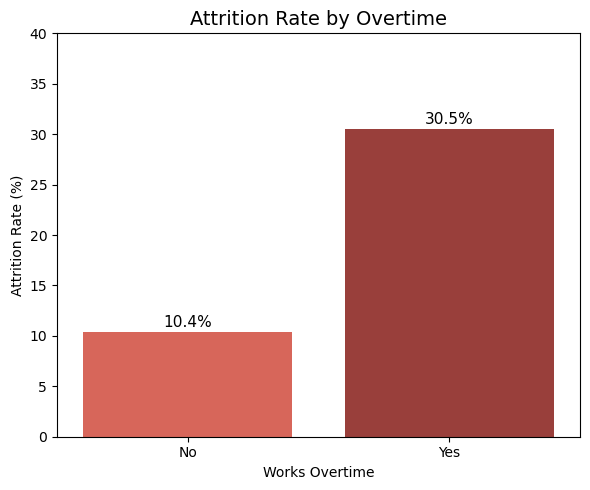

OverTime
No     10.4
Yes    30.5
Name: Attrition_Num, dtype: float64


In [21]:
# Attrition rate by overtime
ot_attrition = df.groupby('OverTime')['Attrition_Num'].mean().mul(100).round(1)

# Plot - fixed for newer seaborn version
plt.figure(figsize=(6, 5))
sns.barplot(x=ot_attrition.index, y=ot_attrition.values, 
            hue=ot_attrition.index, palette='Reds_d', legend=False)
plt.title('Attrition Rate by Overtime', fontsize=14)
plt.xlabel('Works Overtime')
plt.ylabel('Attrition Rate (%)')
plt.ylim(0, 40)

# Add % labels
for i, val in enumerate(ot_attrition.values):
    plt.text(i, val + 0.5, f'{val}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

print(ot_attrition)

Employees who work overtime are 3x more likely to leave than those who don't.

# Does salary affect attrition?

# Average salary of people who left vs stayed
salary_attrition = df.groupby('Attrition')['MonthlyIncome'].mean().round(0)

# Plot
plt.figure(figsize=(6, 5))
sns.barplot(x=salary_attrition.index, y=salary_attrition.values,
            hue=salary_attrition.index, palette='Greens_d', legend=False)
plt.title('Average Salary: Left vs Stayed', fontsize=14)
plt.xlabel('Attrition')
plt.ylabel('Average Monthly Income ($)')
plt.ylim(0, 7000)

# Add $ labels
for i, val in enumerate(salary_attrition.values):
    plt.text(i, val + 50, f'${val:,.0f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

print(salary_attrition)

# Which age group leaves the most?

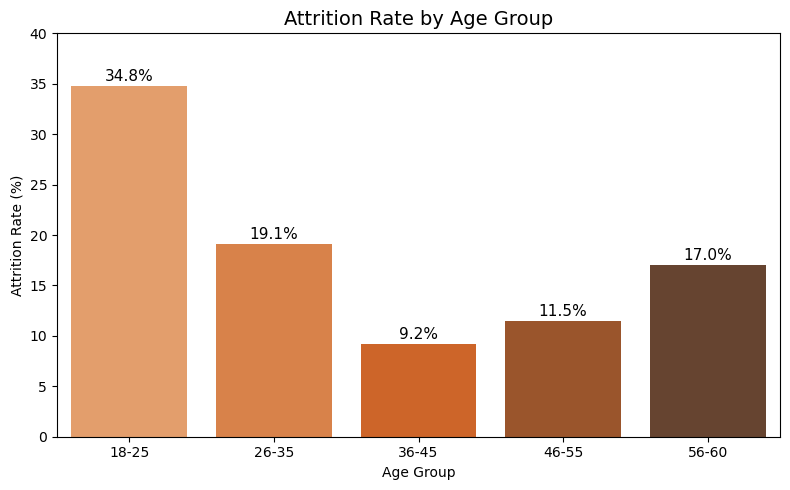

AgeGroup
18-25    34.8
26-35    19.1
36-45     9.2
46-55    11.5
56-60    17.0
Name: Attrition_Num, dtype: float64


In [25]:
# Create age groups
df['AgeGroup'] = pd.cut(df['Age'], 
                         bins=[18, 25, 35, 45, 55, 60],
                         labels=['18-25', '26-35', '36-45', '46-55', '56-60'])

# Attrition rate by age group
age_attrition = df.groupby('AgeGroup', observed=True)['Attrition_Num'].mean().mul(100).round(1)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=age_attrition.index, y=age_attrition.values,
            hue=age_attrition.index, palette='Oranges_d', legend=False)
plt.title('Attrition Rate by Age Group', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Attrition Rate (%)')
plt.ylim(0, 40)

# Add % labels
for i, val in enumerate(age_attrition.values):
    plt.text(i, val + 0.5, f'{val}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

print(age_attrition)

Young employees (18-25) are leaving the most — likely because they are entry level, underpaid, and still exploring career options.
56-60 age group is surprisingly high at 17% — these are likely early retirements or senior employees getting better offers elsewhere.

# Correlation heatmap

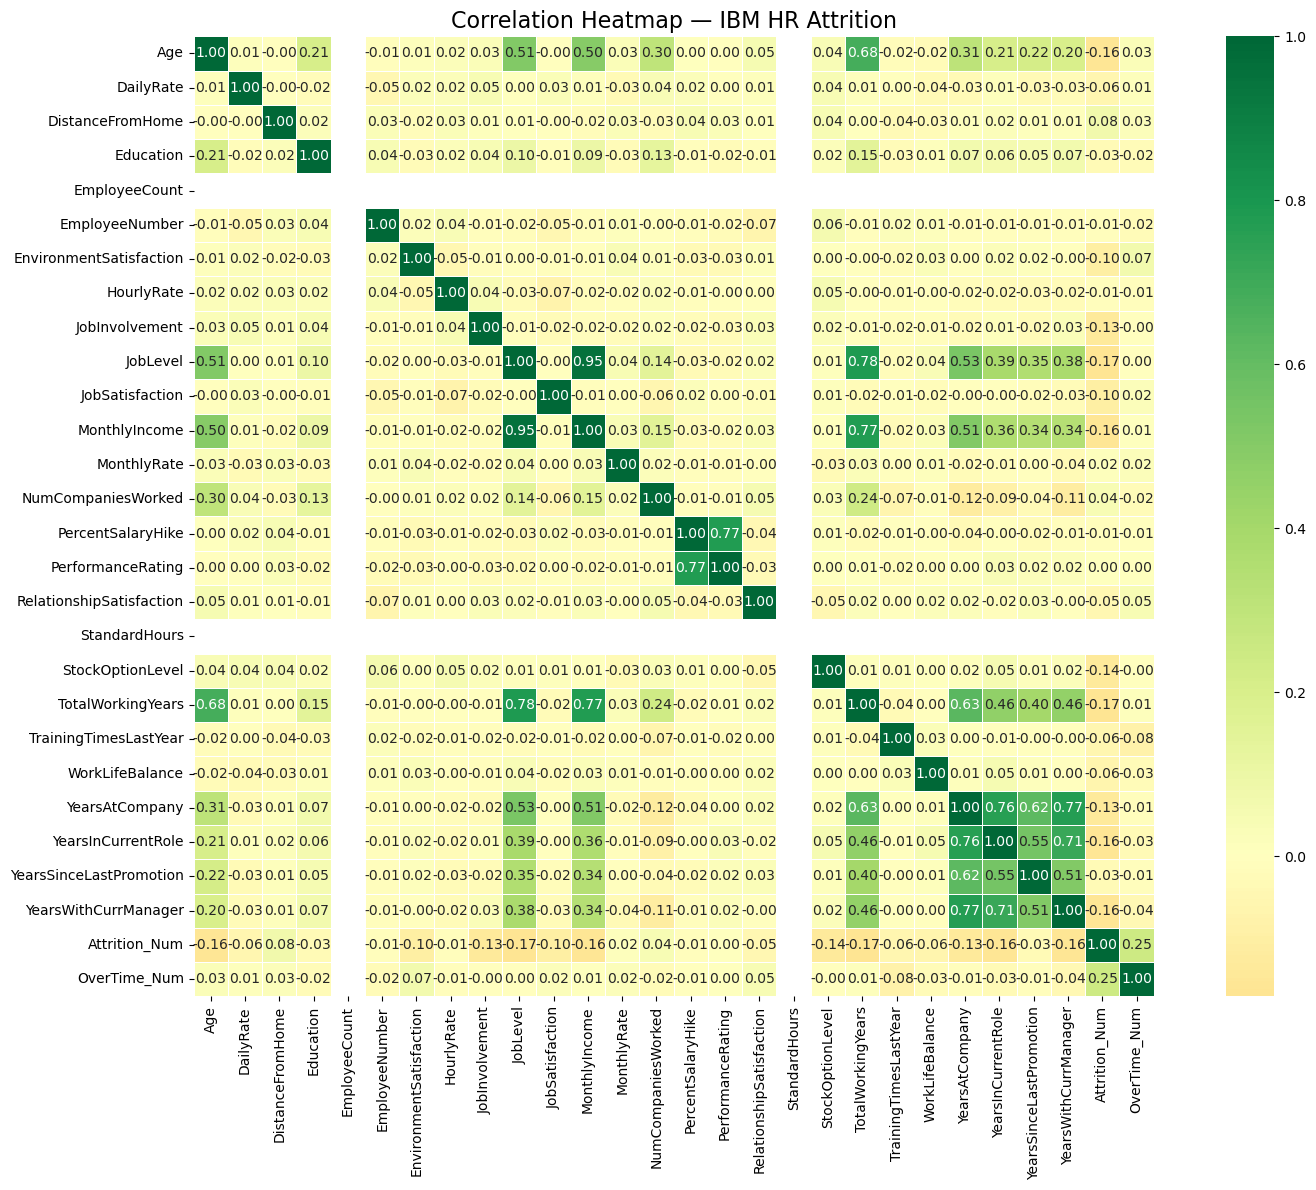

In [29]:
# Select only numeric columns
numeric_df = df.select_dtypes(include='number')

# Calculate correlation
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr, 
            annot=True,          # show numbers
            fmt='.2f',           # 2 decimal places
            cmap='RdYlGn',       # red=negative, green=positive
            center=0,            # center color at 0
            square=True,         # square cells
            linewidths=0.5)      # grid lines

plt.title('Correlation Heatmap — IBM HR Attrition', fontsize=16)
plt.tight_layout()
plt.show()

In [31]:
# Which factors correlate most with attrition?
attrition_corr = numeric_df.corr()['Attrition_Num'].drop('Attrition_Num')
attrition_corr = attrition_corr.sort_values(ascending=False)

print("FACTORS MOST CORRELATED WITH ATTRITION")
print("\nTop factors that INCREASE attrition:")
print(attrition_corr.head(5))
print("\nTop factors that DECREASE attrition:")
print(attrition_corr.tail(5))

FACTORS MOST CORRELATED WITH ATTRITION

Top factors that INCREASE attrition:
OverTime_Num          0.246118
DistanceFromHome      0.077924
NumCompaniesWorked    0.043494
MonthlyRate           0.015170
PerformanceRating     0.002889
Name: Attrition_Num, dtype: float64

Top factors that DECREASE attrition:
YearsInCurrentRole   -0.160545
JobLevel             -0.169105
TotalWorkingYears    -0.171063
EmployeeCount              NaN
StandardHours              NaN
Name: Attrition_Num, dtype: float64


In [32]:
# Drop NaN correlations
attrition_corr = attrition_corr.dropna()

# Show clean top and bottom 5
print("=== CLEAN CORRELATION WITH ATTRITION ===")
print("\nTop 5 factors INCREASING attrition:")
print(attrition_corr.head(5))

print("\nTop 5 factors DECREASING attrition:")
print(attrition_corr.tail(5))

=== CLEAN CORRELATION WITH ATTRITION ===

Top 5 factors INCREASING attrition:
OverTime_Num          0.246118
DistanceFromHome      0.077924
NumCompaniesWorked    0.043494
MonthlyRate           0.015170
PerformanceRating     0.002889
Name: Attrition_Num, dtype: float64

Top 5 factors DECREASING attrition:
Age                  -0.159205
MonthlyIncome        -0.159840
YearsInCurrentRole   -0.160545
JobLevel             -0.169105
TotalWorkingYears    -0.171063
Name: Attrition_Num, dtype: float64


Young, low paid, overtime working, long commute employees are most likely to leave

# cost model

In [27]:
avg_salary_left = df[df['Attrition'] == 'Yes']['MonthlyIncome'].mean()
replacement_cost_per_employee = avg_salary_left * 6
total_employees_left = df['Attrition_Num'].sum()
total_cost = replacement_cost_per_employee * total_employees_left

print("ATTRITION COST MODEL")
print(f"Employees who left:            {total_employees_left}")
print(f"Avg monthly salary (leavers):  ${avg_salary_left:,.0f}")
print(f"Replacement cost per person:   ${replacement_cost_per_employee:,.0f}")
print(f"Total cost to company:         ${total_cost:,.0f}")
print(f"Total cost in millions:        ${total_cost/1_000_000:.1f}M")

# Cost by department
print("\nCOST BY DEPARTMENT")
dept_cost = df[df['Attrition'] == 'Yes'].groupby('Department')['MonthlyIncome'].agg(['mean', 'count'])
dept_cost.columns = ['Avg Salary', 'People Left']
dept_cost['Total Cost'] = dept_cost['Avg Salary'] * 6 * dept_cost['People Left']
dept_cost['Total Cost'] = dept_cost['Total Cost'].apply(lambda x: f"${x:,.0f}")
print(dept_cost)

ATTRITION COST MODEL
Employees who left:            237
Avg monthly salary (leavers):  $4,787
Replacement cost per person:   $28,723
Total cost to company:         $6,807,246
Total cost in millions:        $6.8M

COST BY DEPARTMENT
                         Avg Salary  People Left  Total Cost
Department                                                  
Human Resources         3715.750000           12    $267,534
Research & Development  4108.075188          133  $3,278,244
Sales                   5908.456522           92  $3,261,468


# Cost visualization

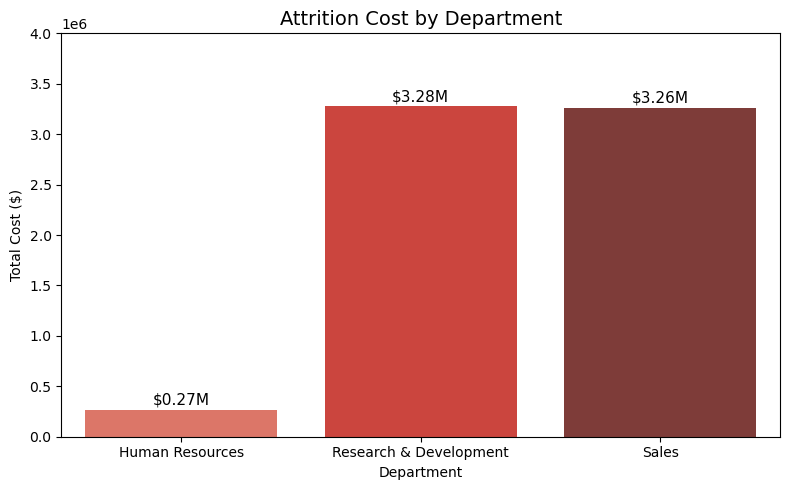

In [28]:
# Cost visualization
dept_names = ['Human Resources', 'Research & Development', 'Sales']
costs = [267534, 3278244, 3261468]

plt.figure(figsize=(8, 5))
sns.barplot(x=dept_names, y=costs,
            hue=dept_names, palette='Reds_d', legend=False)
plt.title('Attrition Cost by Department', fontsize=14)
plt.xlabel('Department')
plt.ylabel('Total Cost ($)')
plt.ylim(0, 4000000)

# Add $ labels
for i, val in enumerate(costs):
    plt.text(i, val + 50000, f'${val/1_000_000:.2f}M', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

# Model Building 

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Select features (columns the model learns from)
features = ['Age', 'MonthlyIncome', 'OverTime_Num', 'DistanceFromHome',
            'YearsAtCompany', 'TotalWorkingYears', 'JobLevel',
            'NumCompaniesWorked', 'YearsInCurrentRole', 'YearsSinceLastPromotion']

# X = inputs, y = what we want to predict
X = df[features]
y = df['Attrition_Num']

# Split data — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 1176
Testing rows: 294


In [34]:
# Build the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train it — this is where the model learns from the data
rf_model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [36]:
# Make predictions on test data
y_pred = rf_model.predict(X_test)

# Check accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy*100:.1f}%")

# Detailed report
print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Left']))

Model Accuracy: 84.7%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Stayed       0.88      0.96      0.92       255
        Left       0.29      0.10      0.15        39

    accuracy                           0.85       294
   macro avg       0.58      0.53      0.53       294
weighted avg       0.80      0.85      0.81       294



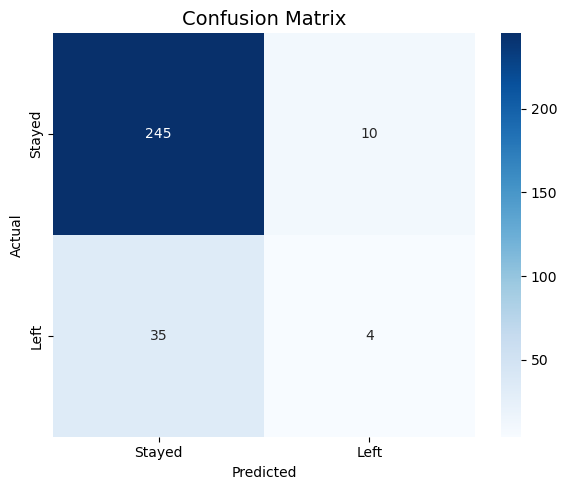

In [37]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Left'],
            yticklabels=['Stayed', 'Left'])
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# SMOTE to balance the data

In [38]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Install if needed
# pip install imbalanced-learn

# Balance the classes
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_bal))

Before SMOTE: Counter({0: 978, 1: 198})
After SMOTE: Counter({0: 978, 1: 978})


SMOTE created 780 new synthetic examples of employees who left — now the model sees equal numbers of both groups and can learn properly!

# Retrain the model on balanced data

In [41]:
# Retrain on balanced data
rf_model_bal = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_bal.fit(X_train_bal, y_train_bal)

# Predict
y_pred_bal = rf_model_bal.predict(X_test)

# Accuracy
accuracy_bal = accuracy_score(y_test, y_pred_bal)
print(f"New Model Accuracy: {accuracy_bal*100:.1f}%")

# Detailed report
print("\nNEW CLASSIFICATION REPORT")
print(classification_report(y_test, y_pred_bal, target_names=['Stayed', 'Left']))

New Model Accuracy: 78.2%

NEW CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Stayed       0.90      0.84      0.87       255
        Left       0.27      0.38      0.32        39

    accuracy                           0.78       294
   macro avg       0.59      0.61      0.59       294
weighted avg       0.82      0.78      0.80       294



The old model only caught 10% of people who left.
The new model catches 38% of people who left.That's nearly 4x better at finding the people we actually care about!

For HR, missing an employee who is about to leave is very costly. We'd rather flag too many than miss the real ones.

In [45]:
# Try tuning the model
rf_model_tuned = RandomForestClassifier(
    n_estimators=200,        # more trees
    max_depth=10,            # limit tree depth
    min_samples_split=5,     # need 5 samples to split
    class_weight='balanced', # another way to handle imbalance
    random_state=42
)

rf_model_tuned.fit(X_train_bal, y_train_bal)

# Predict
y_pred_tuned = rf_model_tuned.predict(X_test)

# Results
print(f"Tuned Model Accuracy: {accuracy_score(y_test, y_pred_tuned)*100:.1f}%")
print("\nTUNED CLASSIFICATION REPORT")
print(classification_report(y_test, y_pred_tuned, target_names=['Stayed', 'Left']))

Tuned Model Accuracy: 76.5%

TUNED CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Stayed       0.90      0.82      0.86       255
        Left       0.26      0.41      0.32        39

    accuracy                           0.77       294
   macro avg       0.58      0.61      0.59       294
weighted avg       0.82      0.77      0.79       294



The tuned model is our winner because:
It catches 41% of employees who will leave — highest of all three models. In HR that's what matters most — finding at risk employees before they resign.

# Feature importance

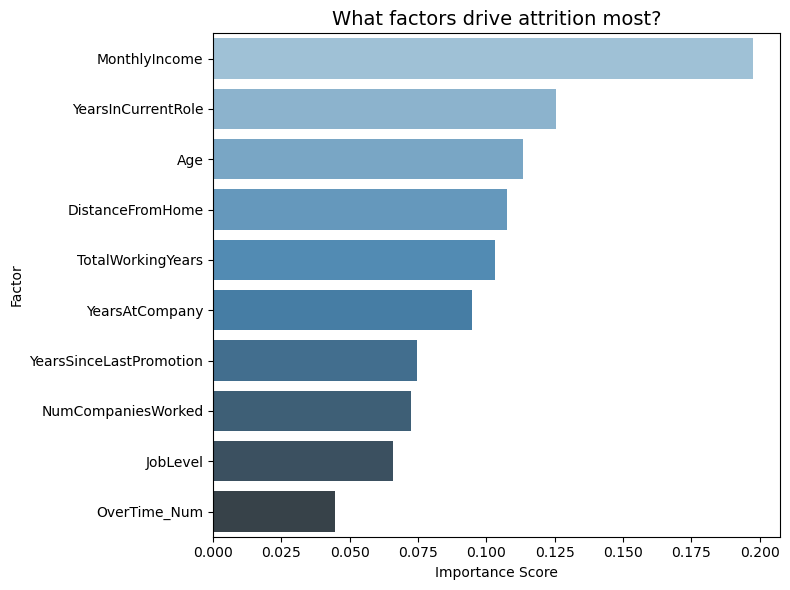

=== FEATURE IMPORTANCE ===
                Feature  Importance
          MonthlyIncome    0.197593
     YearsInCurrentRole    0.125653
                    Age    0.113374
       DistanceFromHome    0.107727
      TotalWorkingYears    0.103222
         YearsAtCompany    0.094883
YearsSinceLastPromotion    0.074632
     NumCompaniesWorked    0.072481
               JobLevel    0.065768
           OverTime_Num    0.044667


In [46]:
# Feature importance
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model_tuned.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot
plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature',
            data=feature_importance,
            hue='Feature', palette='Blues_d', legend=False)
plt.title('What factors drive attrition most?', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Factor')
plt.tight_layout()
plt.show()

# Print numbers
print("FEATURE IMPORTANCE")
print(feature_importance.to_string(index=False))

The model tells us that a young, low paid, junior employee who hasn't been promoted in a while, lives far from office and has worked at multiple companies is the highest risk employee to lose. Overtime alone isn't enough,it's the combination of all these factors together that predicts attrition.

In [47]:
import joblib

# Save the model
joblib.dump(rf_model_tuned, 'hr_attrition_model.pkl')
print("Model saved!")

# Export clean data for Power BI
df.to_csv('hr_attrition_clean.csv', index=False)
print("Clean data exported!")
print(f"Final shape: {df.shape}")

Model saved!
Clean data exported!
Final shape: (1470, 37)
